In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [12]:
data = pd.read_csv("loan_data.csv")
data.head(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [13]:
labelEncoder_person_gender = LabelEncoder()
labelEncoder_person_education = LabelEncoder()
labelEncoder_person_home_ownership = LabelEncoder()
labelEncoder_loan_intent = LabelEncoder()
labelEncoder_previous_loan_defaults_on_file = LabelEncoder()

In [14]:
data["gender_numeric"] = labelEncoder_person_gender.fit_transform(data["person_gender"])
data["education_numeric"] = labelEncoder_person_education.fit_transform(data["person_education"])
data["ownership_numeric"] = labelEncoder_person_home_ownership.fit_transform(data["person_home_ownership"])
data["intent_numeric"] = labelEncoder_loan_intent.fit_transform(data["loan_intent"])
data["loan_default_numeric"] = labelEncoder_previous_loan_defaults_on_file.fit_transform(data["previous_loan_defaults_on_file"])

In [15]:
selected_columns = ['person_age', 'person_income',
       'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status',
       'gender_numeric', 'education_numeric', 'ownership_numeric',
       'intent_numeric', 'loan_default_numeric']

In [16]:
dati_puliti = data[selected_columns]
dati_puliti

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,gender_numeric,education_numeric,ownership_numeric,intent_numeric,loan_default_numeric
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,4,3,4,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,3,2,1,1
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,3,0,3,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,0,1,3,3,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,1,4,3,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1,1,0,3,3,0
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1,0,0,3,2,0
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1,1,0,3,0,0
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1,1,1,3,1,0


In [25]:
feature = ['person_age', 'person_income',
       'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'education_numeric', 'ownership_numeric',
       'intent_numeric', 'loan_default_numeric']
output = ['loan_status']
selected_data = data[feature+output]
selected_data.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,education_numeric,ownership_numeric,intent_numeric,loan_default_numeric,loan_status
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,4,3,4,0,1
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,3,2,1,1,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,3,0,3,0,1
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,3,3,0,1
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,4,3,3,0,1


In [26]:
X = selected_data[feature].to_numpy()
y = selected_data[output].to_numpy()

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [28]:
rf = RandomForestClassifier(max_depth=3, n_estimators=50)

In [29]:
rf.fit(X_train, y_train.reshape(-1))

,n_estimators,50
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf.score(X_test, y_test)

0.8639259259259259

In [31]:
#Come calcolare max_depth ottimale!
lista_profondita = list(range(1, 15))
#lista_profondita
lista_score_test=[]
lista_score_training=[]
for profondita in lista_profondita:
    #addestriamo un random forest con profondità del for
    rf = RandomForestClassifier(max_depth=profondita, n_estimators=100)
    rf.fit(X_train, y_train.reshape(-1))
    lista_score_test.append(rf.score(X_test, y_test))
    lista_score_training.append(rf.score(X_train, y_train))

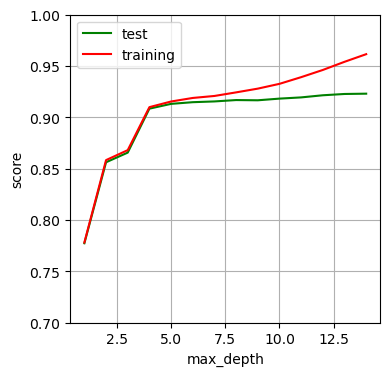

In [39]:
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(lista_profondita, lista_score_test, color="green", label="test")
ax.plot(lista_profondita, lista_score_training, color="red", label="training")
ax.set_xlabel("max_depth")
ax.set_ylabel("score")
ax.grid()
ax.set_ylim(0.7, 1)
ax.legend()
plt.show()

In [40]:
# il training tende ad aumentare perchè impara a memoria

In [42]:
rf = RandomForestClassifier(max_depth=5, n_estimators=50)
rf.fit(X_train, y_train.reshape(-1))

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
rf.score(X_test, y_test)

0.9121481481481482

## Per trovare N_estimators

si procede nello stesso modo tenendo fisso max_depth = 5

In [44]:
rf.feature_importances_

array([6.62288477e-04, 9.46925936e-02, 4.08509544e-04, 2.65900547e-02,
       1.44398334e-01, 2.46680555e-01, 3.36207099e-04, 7.24493314e-03,
       7.03875321e-05, 7.74684141e-02, 1.08242213e-02, 3.90623502e-01])

In [46]:
features = ['person_age', 'person_income',
       'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'education_numeric', 'ownership_numeric',
       'intent_numeric', 'loan_default_numeric']

Random forest è in grado di calcolare l'importanza delle diverse feature! Questi numeri sopra sono l'importanza delle feature.
La loro somma vale 1, numeri più grandi corrispondono a importanza più grande

In [48]:
for feature, importance in zip(features, rf.feature_importances_):
    print(f'{feature} : {importance:.3f}')

person_age : 0.001
person_income : 0.095
person_emp_exp : 0.000
loan_amnt : 0.027
loan_int_rate : 0.144
loan_percent_income : 0.247
cb_person_cred_hist_length : 0.000
credit_score : 0.007
education_numeric : 0.000
ownership_numeric : 0.077
intent_numeric : 0.011
loan_default_numeric : 0.391


#### Vediamo così l'importanza di ogni feature nel random forest, per esempio education è inutile

Quindi randomForest è uno strumento per fare feature engineering

Spesso useremo random forest per selezionare le feature più importanti, successivamente addestreremo un MLP soltanto con queste feature.

In [50]:
# trovare quindi gli n_estimators, suggerimento = lista_estimators = 100

In [51]:
#Come calcolare max_depth ottimale!
lista_n_alberi = list(range(10, 300, 50))
#lista_profondita
lista_score_test=[]
lista_score_training=[]
for albero in lista_n_alberi:
    #addestriamo un random forest con profondità del for
    rf = RandomForestClassifier(max_depth=5, n_estimators=albero)
    rf.fit(X_train, y_train.reshape(-1))
    lista_score_test.append(rf.score(X_test, y_test))
    lista_score_training.append(rf.score(X_train, y_train))

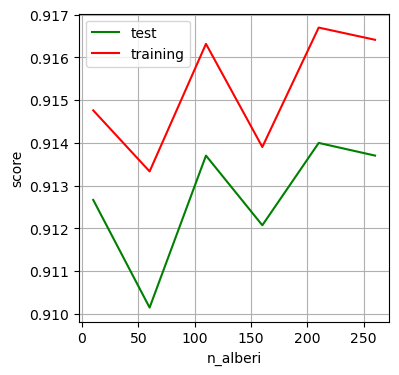

In [52]:
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(lista_n_alberi, lista_score_test, color="green", label="test")
ax.plot(lista_n_alberi, lista_score_training, color="red", label="training")
ax.set_xlabel("n_alberi")
ax.set_ylabel("score")
ax.grid()
#ax.set_ylim(0.7, 1)
ax.legend()
plt.show()